In [1]:
import pandas as pd
import numpy as np

print("AI Environment Ready")

AI Environment Ready


In [2]:
import pandas as pd

df = pd.read_csv("../dataset/subway_congestion.csv")

print(df.head())

  요일구분   호선  역번호  출발역 상하구분  5시30분  6시00분  6시30분  7시00분  7시30분  ...  20시00분  \
0   평일  1호선  150  서울역   상선    8.0   20.7   23.2   41.2   67.7  ...    20.5   
1   평일  1호선  150  서울역   하선   11.2   11.1   17.7   24.8   41.7  ...    41.0   
2   평일  1호선  151   시청   상선    6.7   14.8   18.8   32.7   51.8  ...    24.9   
3   평일  1호선  151   시청   하선    8.6   10.4   17.8   24.0   36.8  ...    37.1   
4   평일  1호선  152   종각   상선    6.1   13.3   11.4   20.9   31.0  ...    32.7   

   20시30분  21시00분  21시30분  22시00분  22시30분  23시00분  23시30분  00시00분  00시30분  
0    18.6    20.0    15.0    16.5    16.8    14.0     9.2     5.9     1.3  
1    40.4    43.3    38.0    39.5    30.2    18.7    12.8     8.6     0.0  
2    22.7    24.6    18.5    20.6    20.4    17.2    10.6     6.6     1.3  
3    37.2    41.8    31.5    34.6    25.9    16.6    11.3     5.9     0.4  
4    30.8    33.8    25.1    26.9    27.5    23.3    12.8     7.5     1.2  

[5 rows x 44 columns]


In [3]:
print(df.columns)

Index(['요일구분', '호선', '역번호', '출발역', '상하구분', '5시30분', '6시00분', '6시30분', '7시00분',
       '7시30분', '8시00분', '8시30분', '9시00분', '9시30분', '10시00분', '10시30분',
       '11시00분', '11시30분', '12시00분', '12시30분', '13시00분', '13시30분', '14시00분',
       '14시30분', '15시00분', '15시30분', '16시00분', '16시30분', '17시00분', '17시30분',
       '18시00분', '18시30분', '19시00분', '19시30분', '20시00분', '20시30분', '21시00분',
       '21시30분', '22시00분', '22시30분', '23시00분', '23시30분', '00시00분', '00시30분'],
      dtype='str')


In [4]:
# Time columns
time_columns = [
    '5시30분', '6시00분', '6시30분', '7시00분',
    '7시30분', '8시00분', '8시30분', '9시00분',
    '9시30분', '10시00분', '10시30분',
    '11시00분', '11시30분', '12시00분',
    '12시30분', '13시00분', '13시30분',
    '14시00분', '14시30분', '15시00분',
    '15시30분', '16시00분', '16시30분',
    '17시00분', '17시30분', '18시00분',
    '18시30분', '19시00분', '19시30분',
    '20시00분', '20시30분', '21시00분',
    '21시30분', '22시00분', '22시30분',
    '23시00분', '23시30분', '00시00분',
    '00시30분'
]

# Convert wide format to long format
long_df = df.melt(
    id_vars=['요일구분', '호선', '역번호', '출발역', '상하구분'],
    value_vars=time_columns,
    var_name='시간',
    value_name='혼잡도'
)

# Show result
print(long_df.head())

  요일구분   호선  역번호  출발역 상하구분     시간   혼잡도
0   평일  1호선  150  서울역   상선  5시30분   8.0
1   평일  1호선  150  서울역   하선  5시30분  11.2
2   평일  1호선  151   시청   상선  5시30분   6.7
3   평일  1호선  151   시청   하선  5시30분   8.6
4   평일  1호선  152   종각   상선  5시30분   6.1


In [5]:
print(long_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 195000 entries, 0 to 194999
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   요일구분    195000 non-null  str    
 1   호선      195000 non-null  str    
 2   역번호     195000 non-null  int64  
 3   출발역     195000 non-null  str    
 4   상하구분    195000 non-null  str    
 5   시간      195000 non-null  str    
 6   혼잡도     195000 non-null  float64
dtypes: float64(1), int64(1), str(5)
memory usage: 10.4 MB
None


In [6]:
print(long_df.isnull().sum())

요일구분    0
호선      0
역번호     0
출발역     0
상하구분    0
시간      0
혼잡도     0
dtype: int64


In [7]:
# Extract hour from 시간 column
long_df['Hour'] = long_df['시간'].str.extract(r'(\d+)').astype(int)

# Create weekend flag
long_df['IsWeekend'] = long_df['요일구분'].apply(
    lambda x: 1 if x != '평일' else 0
)

# Create rush hour flag
long_df['RushHour'] = long_df['Hour'].apply(
    lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0
)

# Show results
print(long_df[['시간', 'Hour', 'IsWeekend', 'RushHour']].head(10))

      시간  Hour  IsWeekend  RushHour
0  5시30분     5          0         0
1  5시30분     5          0         0
2  5시30분     5          0         0
3  5시30분     5          0         0
4  5시30분     5          0         0
5  5시30분     5          0         0
6  5시30분     5          0         0
7  5시30분     5          0         0
8  5시30분     5          0         0
9  5시30분     5          0         0


In [8]:
# Input features (X)
X = long_df[['Hour', 'IsWeekend', 'RushHour']]

# Target value (y)
y = long_df['혼잡도']

print(X.head())
print(y.head())

   Hour  IsWeekend  RushHour
0     5          0         0
1     5          0         0
2     5          0         0
3     5          0         0
4     5          0         0
0     8.0
1    11.2
2     6.7
3     8.6
4     6.1
Name: 혼잡도, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 156000
Testing data: 39000


In [11]:
from sklearn.ensemble import RandomForestRegressor

# Create model
model = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("AI Model Trained Successfully")

AI Model Trained Successfully


In [12]:
# Predict congestion on test data
predictions = model.predict(X_test)

# Show first 10 predictions
print(predictions[:10])

[32.3062621  32.27545661 34.16795772 21.05600943 21.05600943 12.3253943
 24.25586491 16.51875417 24.25586491 34.16795772]


In [15]:
# Encoding Text Features

In [16]:
from sklearn.preprocessing import LabelEncoder

# Create encoders
line_encoder = LabelEncoder()
station_encoder = LabelEncoder()
direction_encoder = LabelEncoder()

# Convert text into numbers
long_df['호선_encoded'] = line_encoder.fit_transform(long_df['호선'])
long_df['출발역_encoded'] = station_encoder.fit_transform(long_df['출발역'])
long_df['상하구분_encoded'] = direction_encoder.fit_transform(long_df['상하구분'])

# Show results
print(
    long_df[
        [
            '호선',
            '호선_encoded',
            '출발역',
            '출발역_encoded'
        ]
    ].head()
)

    호선  호선_encoded  출발역  출발역_encoded
0  1호선           0  서울역          119
1  1호선           0  서울역          119
2  1호선           0   시청          135
3  1호선           0   시청          135
4  1호선           0   종각          206


In [ ]:
#Create BETTER AI Features

In [17]:
# Improved input features
X = long_df[
    [
        'Hour',
        'IsWeekend',
        'RushHour',
        '호선_encoded',
        '출발역_encoded',
        '상하구분_encoded'
    ]
]

# Target
y = long_df['혼잡도']

In [ ]:
# 10. Retrain AI With Improved Features

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 156000
Testing data: 39000


In [ ]:
#Train Improved Random Forest Model

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Create improved model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("Improved AI Model Trained Successfully")

Improved AI Model Trained Successfully


In [20]:
#Generating improved predictions 

In [21]:
# Generate predictions
predictions = model.predict(X_test)

# Show first 10 predictions
print(predictions[:10])

[37.05464508 33.70658386 64.01427766 54.47088328  9.38761454  2.28138936
 60.45229008  4.7140265  12.34265791 24.16699921]


In [22]:
#Evaluation of improved model 

In [23]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate metrics
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Improved Mean Absolute Error:", mae)
print("Improved R2 Score:", r2)

Improved Mean Absolute Error: 5.160109164361387
Improved R2 Score: 0.8754800615678532


In [26]:
#Feature Importance Analysis
#Which factors most influence congestion?

#Example:

#station → 50%
#rush hour → 20%
#line → 15% 

        Feature  Importance
4   출발역_encoded    0.476573
0          Hour    0.292508
3    호선_encoded    0.094647
5  상하구분_encoded    0.061123
2      RushHour    0.042546
1     IsWeekend    0.032602


C:\Users\abhin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\abhin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\abhin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\abhin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\abhin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages

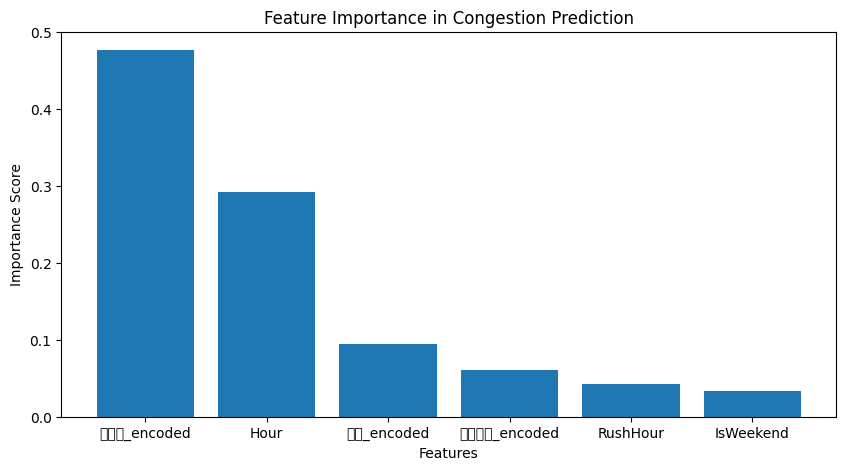

In [27]:
import matplotlib.pyplot as plt

# Feature names
features = X.columns

# Importance values
importance = model.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sort values
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Show table
print(importance_df)

# Plot graph
plt.figure(figsize=(10,5))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance in Congestion Prediction")

plt.show()

In [28]:
# 12. Real-Time Congestion Prediction Function

In [29]:
def predict_congestion(
    hour,
    is_weekend,
    rush_hour,
    line,
    station,
    direction
):
    
    # Encode categorical values
    line_encoded = line_encoder.transform([line])[0]
    station_encoded = station_encoder.transform([station])[0]
    direction_encoded = direction_encoder.transform([direction])[0]

    # Create input dataframe
    input_data = pd.DataFrame({
        'Hour': [hour],
        'IsWeekend': [is_weekend],
        'RushHour': [rush_hour],
        '호선_encoded': [line_encoded],
        '출발역_encoded': [station_encoded],
        '상하구분_encoded': [direction_encoded]
    })

    # Predict congestion
    prediction = model.predict(input_data)

    return prediction[0]

In [30]:
#Testing the AI prediction again 

In [31]:
result = predict_congestion(
    hour=8,
    is_weekend=0,
    rush_hour=1,
    line='1호선',
    station='서울역',
    direction='상선'
)

print("Predicted Congestion:", result)

Predicted Congestion: 82.58043333333335


In [32]:
#Predicted Congestion: 82.58

#Meaning:

#At:

#Seoul Station,
#8 AM,
#weekday,
#rush hour,
#line 1,
#upward direction,


In [33]:
#AI Component Status-done
#Dataset preprocessing	-done
#Time-series transformation	-done
#Feature engineering	-done
#Categorical encoding	-done
#Random Forest AI model	-done
#High accuracy prediction	-done
#Feature importance analysis	-done
# prediction function -done

In [34]:
# Alternative Low-Congestion Recommendation System

In [35]:
def recommend_less_crowded_stations(
    hour,
    is_weekend,
    rush_hour,
    line,
    direction,
    top_n=5
):

    recommendations = []

    # Get unique stations
    stations = long_df['출발역'].unique()

    for station in stations:

        try:
            # Predict congestion
            congestion = predict_congestion(
                hour=hour,
                is_weekend=is_weekend,
                rush_hour=rush_hour,
                line=line,
                station=station,
                direction=direction
            )

            recommendations.append({
                'Station': station,
                'Predicted_Congestion': congestion
            })

        except:
            pass

    # Convert to dataframe
    recommendations_df = pd.DataFrame(recommendations)

    # Sort by lowest congestion
    recommendations_df = recommendations_df.sort_values(
        by='Predicted_Congestion'
    )

    # Return top recommendations
    return recommendations_df.head(top_n)

In [ ]:
#Testing 

In [36]:
recommendations = recommend_less_crowded_stations(
    hour=8,
    is_weekend=0,
    rush_hour=1,
    line='1호선',
    direction='상선',
    top_n=10
)

print(recommendations)

    Station  Predicted_Congestion
91      불암산             17.312694
67      독립문             17.663240
164     독바위             17.696453
194     도봉산             18.116140
214      내방             18.523095
204     사가정             19.961521
17      한양대             20.521569
101   한성대입구             20.521569
180      창신             21.262779
227      천왕             21.262779
